# Clustering


Dans ce notebook, nous explorons l'utilisation de méthodes d'apprentissage non supervisé (notamment K-Means et AgglomerativeClustering) pour regrouper les communes selon leurs niveaux de vulnérabilité face au changement climatique et leurs capacités financières.

L'objectif est d'identifier des groupes (clusters) de communes présentant des profils de risques et des caractéristiques socio-économiques similaires.

Les **features (variables)** clés qui sont considérées pour ce clustering sont :

- **Exposition aux risques naturels** :
  - Maisons exposées au RGA (Retrait-Gonflement des Argiles).
  - Maisons exposées aux inondations (TRI).
- **Historique des catastrophes naturelles (CatNat)** :
  - Nombre d'événements CatNat sur les 20 dernières années.
  - Ratio de reconnaissance des CatNat (reconnues vs non reconnues), permettant d'évaluer la difficulté ou facilité d'indemnisation.
- **Vulnérabilité financière et socio-économique** :
  - Poids médian des primes d'assurance dans le budget de la commune (ratio primes / dépenses de fonctionnement).
  - Revenu médian de la commune.
  - Taux de chômage local.


Notes pour Jacques:

- Virer ICB si on cluster que sur les RGA
- Regarder évolution des primes (en plus du ratio)
- Ajouter les penalités sur les franchise comme pondération des catnats (1 catnat avec franchise doublée = 2 catnats etc, 1 catnat non reconnue = 5 catnats)
- Revenu disponible vs revenu median


## Load tools & parameters


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import duckdb

In [134]:
# ODIS_DUCKDB_FILE = "odis.duckdb"
def run_duckdb_query(q):
    PCC_DUCKDB_FILE = "dev.duckdb"

    con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
    con.sql(f"ATTACH '{PCC_DUCKDB_FILE}' AS pcc;")
    res = con.sql(q)
    df = res.df()
    con.close()
    return df

In [99]:
QUANT_ECRET = 0.05
CATNAT_CODES = ['SEC',  'ICB', 'IRN']
LOOKBACK_YEAR = 2005

In [135]:
q = """
    SHOW TABLES
    """

tables = run_duckdb_query(q)
tables.head(20)

,name
0,azi_gaspar
1,bronze_rei
2,budget_communes
3,budget_per_compte_communes
4,catnat_gaspar
5,ccr_details
6,ccr_main_page
7,datactivist_commune
8,dicrim_gaspar
9,geoportail_ccr_communes


## Gather Features


### Fetch Communes Geometries


In [100]:
# Fetch communes with geometries
com = gpd.read_file('../csv_large/a-com2022-topo-2154.json', layer='a_com2022')
com.set_geometry('geometry', crs='EPSG:2154', inplace=True)
com = com.drop(columns=['xcl2154', 'ycl2154', 'id'])
com.head()

,codgeo,dep,reg,libgeo,geometry
0,01001,01,84,L'Abergement-Clémenciat,"POLYGON ((846981.436 6564107.36, 847017.457 65..."
1,01002,01,84,L'Abergement-de-Varey,"POLYGON ((886027.651 6548170.9, 886157.325 654..."
2,01004,01,84,Ambérieu-en-Bugey,"POLYGON ((884889.404 6539629.931, 884795.75 65..."
3,01005,01,84,Ambérieux-en-Dombes,"POLYGON ((845951.25 6547999.078, 846073.72 654..."
4,01006,01,84,Ambléon,"POLYGON ((901336.361 6521123.305, 902460.201 6..."


### Fetch Communes RGA + TRI


In [101]:
# Fetch Communes with houses RGA + TRI risks
risques_nat = pd.read_parquet('../csv/risques_communes_flat.parquet')
risques_nat.head()

,code_commune_insee,total_maisons,rga_1945_1975_faible,rga_1945_1975_moyen,rga_1945_1975_nul,rga_1945_1975_fort,rga_1976_2020_faible,rga_1976_2020_moyen,rga_1976_2020_nul,rga_1976_2020_fort,...,tri_nul_nul,tri_t01_faible,tri_t01_fort,tri_t01_moyen,tri_t02_faible,tri_t02_fort,tri_t02_moyen,tri_t03_faible,tri_t03_fort,tri_t03_moyen
0,01001,358,21,0,0,0,184,2,0,0,...,358,0,0,0,0,0,0,0,0,0
1,01002,168,1,12,0,0,2,25,3,0,...,168,0,0,0,0,0,0,0,0,0
2,01004,3254,337,165,1,0,930,869,11,0,...,3254,0,0,0,0,0,0,0,0,0
3,01005,616,82,0,0,0,328,0,2,0,...,616,0,0,0,0,0,0,0,0,0
4,01006,62,5,0,0,0,13,0,0,0,...,62,0,0,0,0,0,0,0,0,0


In [102]:
#Add RGA and TRI Score + Cleanup
# RGA Score
period_weights = {
    '1945_1975': 0.5,
    '1976_2020': 1.0,
    'post2020': 0.5,
    'pre1945': 0.0
}

severity_weights = {
    'faible': 1.0,
    'moyen': 5.0,
    'fort': 10.0
}

# Calculate refined weighted sum
rga_weighted = 0
for period, p_weight in period_weights.items():
    if p_weight == 0: continue
    for severity, s_weight in severity_weights.items():
        col = f'rga_{period}_{severity}'
        if col in risques_nat.columns:
            rga_weighted += p_weight * s_weight * risques_nat[col]

risques_nat['rga_score'] = rga_weighted

# TRI Score
tri_cols = [c for c in risques_nat.columns if c.startswith('tri_') and not c.endswith('_nul') and not c == 'tri_nul_nul']
tri_weighted = (
    1 * risques_nat[[c for c in tri_cols if 'faible' in c]].sum(axis=1) +
    3 * risques_nat[[c for c in tri_cols if 'moyen' in c]].sum(axis=1) +
    5 * risques_nat[[c for c in tri_cols if 'fort' in c]].sum(axis=1)
)

risques_nat['tri_score'] = tri_weighted
risques_nat = risques_nat[['code_commune_insee', 'total_maisons', 'rga_score', 'tri_score']].rename(columns={'code_commune_insee':'codgeo'})
risques_nat.head()

,codgeo,total_maisons,rga_score,tri_score
0,01001,358,216.5,0
1,01002,168,160.0,0
2,01004,3254,5961.0,0
3,01005,616,404.0,0
4,01006,62,15.5,0


### Fetch CCR Data


In [103]:
# Fetch CCR Data


ccr_details = pd.read_parquet('../csv_large/ccr_details.parquet')
ccr_details = ccr_details[ccr_details.code_peril.isin(CATNAT_CODES)]
ccr_details = ccr_details[ccr_details.date_debut_evenement.dt.year >= LOOKBACK_YEAR]
# ccr = ccr_details['code_geo'].groupby('code_geo').count()
ccr_details.head()


,code_geo,date_debut_evenement,date_fin_evenement,nom_peril,libelle_avis,code_arrete,code_peril,year
0,07005,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904,ICB,2025
1,07022,2025-11-16,2025-11-17,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025
2,07181,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904,ICB,2025
3,07198,2025-11-15,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904,ICB,2025
4,07219,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025


In [104]:
# Let's Group by CVatNat recognition
ccr = ccr_details.groupby('code_geo').size().to_frame(name='catnat_total')

ccr['catnat_rec'] = ccr_details[ccr_details['libelle_avis'] == 'Reconnue'].groupby('code_geo').size()
ccr['catnat_unrec'] = ccr_details[ccr_details['libelle_avis'] == 'Non reconnue'].groupby('code_geo').size()
ccr['catnat_rec_ratio'] = ccr['catnat_rec'] / ccr['catnat_total']

ccr = ccr.fillna(0).astype(float).reset_index()
ccr = ccr.rename(columns={'code_geo':'codgeo'})
ccr.head()

,codgeo,catnat_total,catnat_rec,catnat_unrec,catnat_rec_ratio
0,01001,1.0,1.0,0.0,1.000000
1,01004,8.0,5.0,3.0,0.625000
2,01007,8.0,7.0,1.0,0.875000
3,01012,3.0,2.0,1.0,0.666667
4,01013,1.0,1.0,0.0,1.000000


### Fetch Primes + Budgets


In [105]:
# Collect the line 6161 from communes budget
primes = pd.read_parquet('../csv/primes_com_flat.parquet').rename(columns={'code_geo':'codgeo'})
primes['primes_median'] = primes.filter(regex='^primes_').median(axis=1)
primes = primes[['codgeo','primes_median']]
primes.head()

,codgeo,primes_median
0,54162,13361.04
1,54180,1890.62
2,54199,5910.81
3,83128,10902.91
4,83129,185749.05


In [106]:
# Import budget dataframe efficiently (file is huge)
usecols=['annee_join', 'com_code', 'agregat', 'montant', 'ptot']
budgets = pd.read_parquet('../csv_large/ofgl-base-communes-consolidee_2.parquet', columns=usecols, filters=[('annee_join', '==', '2024'),('agregat', '==', 'Dépenses de fonctionnement')])
budgets = budgets[['com_code','annee_join','montant','ptot']].rename(columns={'com_code':'codgeo', 'annee_join':'budget_annee', 'montant':'budget_total', 'ptot':'pop_totale'})
budgets.head()

,codgeo,budget_annee,budget_total,pop_totale
0,01204,2024,865297.74,762
1,01015,2024,460647.32,682
2,01187,2024,1512845.81,627
3,01080,2024,1107315.54,660
4,01426,2024,2381631.87,2552


### Fetch Revenus Médians


In [107]:
q = """
SELECT *
FROM dev.main.insee_filosofi_2021
--LIMIT 1000
"""

rev = run_duckdb_query(q)
rev = rev[
    (rev.geo_object == 'COM')
    & (rev.time_period == 2021)
    & (rev.filosofi_measure == 'MED_SL')
][['code_geo', 'obs_value']].rename(columns={'code_geo':'codgeo', 'obs_value':'med_rev'})
rev.head()

,codgeo,med_rev
13,02399,23300.0
22,01368,23300.0
60,01282,25470.0
62,01200,23480.0
86,01398,26370.0


### Fetch Taux de Chômage


In [ ]:
# q = """
# SELECT *
# FROM dev.main.taux_chomage_communes
# -- LIMIT 1000
# """

# chomage = run_duckdb_query(q)
# chomage.shape

(3607, 13)

In [ ]:
chomage = pd.read_csv('../csv_large/DS_RP_EMPLOI_LR_COMP_2022_data.csv', delimiter=';', usecols=['GEO', 'OBS_VALUE', 'TIME_PERIOD', 'PCS', 'GEO_OBJECT','EMPSTA_ENQ'], low_memory=False)
chomage = chomage[
    (chomage.GEO_OBJECT == 'COM')
    & (chomage.PCS == '_T')
    & (chomage.TIME_PERIOD == 2022)
][['GEO', 'EMPSTA_ENQ', 'OBS_VALUE']]
chomage = chomage[chomage.EMPSTA_ENQ == '1T2'].merge(chomage[chomage.EMPSTA_ENQ == '1'], on='GEO', how='left')
chomage['chomage_tx'] = (chomage.OBS_VALUE_x - chomage.OBS_VALUE_y) / chomage.OBS_VALUE_x
chomage = chomage[['GEO', 'chomage_tx']].rename(columns={'GEO':'codgeo'})
chomage.head()

,codgeo,chomage_tx
0,02809,0.000000
1,02486,0.100000
2,02271,0.071429
3,02716,0.040000
4,02790,0.200000


### Join all datapoints


In [110]:
# Mega Join
full = com.copy()
full = full.merge(risques_nat, on='codgeo', how='left')
full = full.merge(ccr, on='codgeo', how='left')
full = full.merge(primes, on='codgeo', how='left')
full = full.merge(budgets, on='codgeo', how='left')
full = full.merge(rev, on='codgeo', how='left')
full = full.merge(chomage, on='codgeo', how='left')

In [111]:
full['primes_ratio'] = full['primes_median'] / full['pop_totale']
full['rga_score_scaled'] = full['rga_score'] / full['total_maisons']
full['tri_score_scaled'] = full['tri_score'] / full['total_maisons']
full['catnat_ratio'] = full['catnat_total'] / full['pop_totale']
full.head(1)

,codgeo,dep,reg,libgeo,geometry,total_maisons,rga_score,tri_score,catnat_total,catnat_rec,...,primes_median,budget_annee,budget_total,pop_totale,med_rev,chomage_tx,primes_ratio,rga_score_scaled,tri_score_scaled,catnat_ratio
0,01001,01,84,L'Abergement-Clémenciat,"POLYGON ((846981.436 6564107.36, 847017.457 65...",358.0,216.5,0.0,1.0,1.0,...,6602.17,2024,595097.77,848.0,25820.0,0.021739,7.785578,0.604749,0.0,0.001179


In [112]:
full.to_parquet('../csv_large/com_with_vuln_factors.parquet')

In [113]:
full.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 37034 entries, 0 to 37033
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   codgeo            37034 non-null  str     
 1   dep               37034 non-null  str     
 2   reg               37034 non-null  str     
 3   libgeo            37034 non-null  str     
 4   geometry          37034 non-null  geometry
 5   total_maisons     36802 non-null  float64 
 6   rga_score         36802 non-null  float64 
 7   tri_score         36802 non-null  float64 
 8   catnat_total      26094 non-null  float64 
 9   catnat_rec        26094 non-null  float64 
 10  catnat_unrec      26094 non-null  float64 
 11  catnat_rec_ratio  26094 non-null  float64 
 12  primes_median     31537 non-null  float64 
 13  budget_annee      37007 non-null  str     
 14  budget_total      37007 non-null  float64 
 15  pop_totale        37007 non-null  float64 
 16  med_rev       

## Clusterings


In [148]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats.mstats import winsorize
from sklearn.cluster import AgglomerativeClustering


In [160]:
# Load the communes with features
cols_to_load = ['codgeo', 'rga_score_scaled', 'tri_score_scaled', 'catnat_rec_ratio', 'med_rev', 'primes_ratio', 'catnat_ratio', 'geometry', 'chomage_tx']
df = pd.read_parquet('../csv_large/com_with_vuln_factors.parquet', columns=cols_to_load, filters=[('catnat_total', '>', 0.0)])
df['geometry'] = gpd.GeoSeries.from_wkb(df['geometry'])

### Clustering with K-Means


(20732, 16)


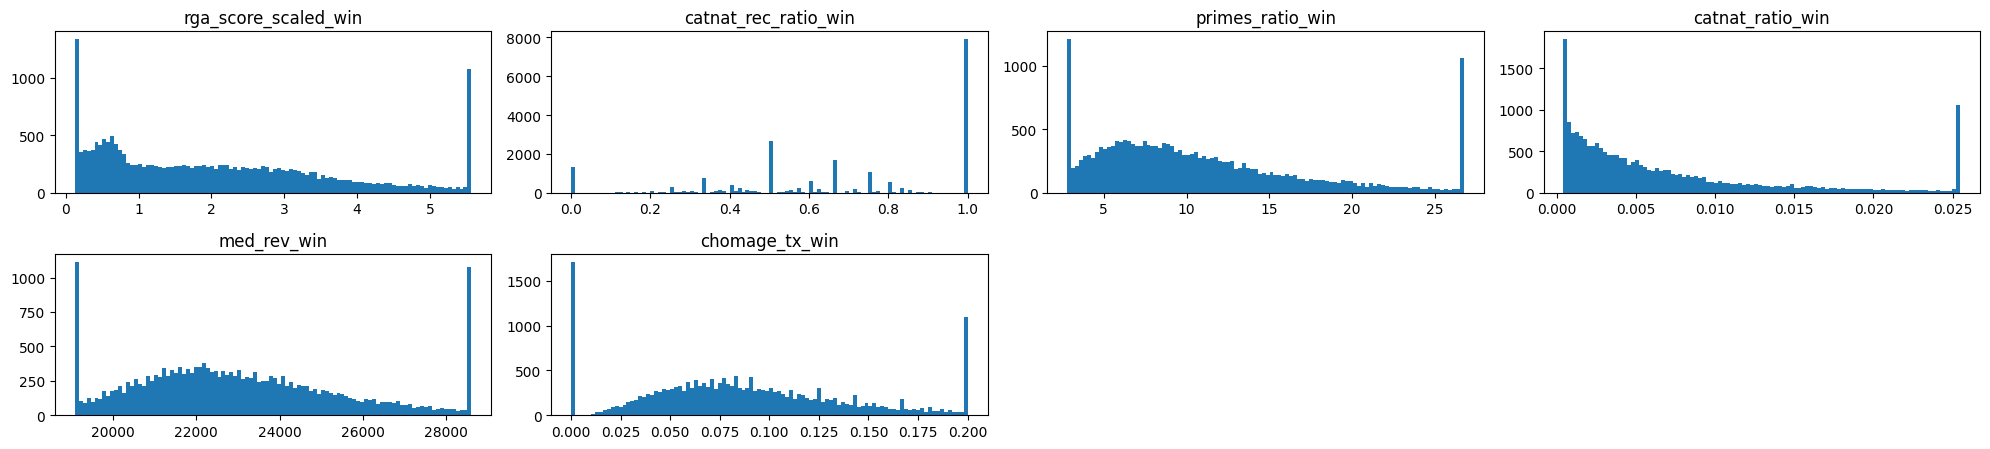

In [156]:
# Let's prepare the data

# 1. On enlève ou remplace les valeurs manquantes + écrettage

df['catnat_rec_ratio'] = df['catnat_rec_ratio'].fillna(1)
df['catnat_ratio'] = df['catnat_ratio'].fillna(0)
df = df.dropna(how='any')

features = [
    'rga_score_scaled', 
    'catnat_rec_ratio', 
    'primes_ratio', 
    'catnat_ratio', 
    'med_rev', 
    # 'catnat_total', 
    # 'tri_score_scaled', 
    'chomage_tx'
    ]

for feat in features:
    df[f'{feat}_win'] = winsorize(df[feat], limits=[QUANT_ECRET, QUANT_ECRET])

features = [feat+'_win' for feat in features] 
X = df[features].copy()

# 3. Standardisation 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# X_scaled = scaler.fit_transform(X_imputed)

print(df.shape)

# Check distribution
df[features].hist(bins=100, figsize=(20, 5), layout=(2, 4), grid=False, edgecolor='none')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])


In [152]:
# 4. Modélisation K-Means 
K_CLUSTERS = 5
kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette Score: {score}")

# 5. Extraction du sens : Profilage des clusters (Expliquer le 'Pourquoi')
profile = df.groupby('cluster')[features].mean().round(3)
profile['nb_communes'] = df.groupby('cluster').size()


# Define columns based on whether higher values are positive or negative indicators
cols_high_is_bad = [c for c in features if c in ('rga_score_scaled_win', 'tri_score_scaled_win', 'primes_ratio_win', 'catnat_ratio_win', 'chomage_tx_win')]
cols_high_is_good = [c for c in features if c not in cols_high_is_bad]

profile.style\
    .background_gradient(cmap='RdYlGn', subset=cols_high_is_good, axis=0)\
    .background_gradient(cmap='RdYlGn_r', subset=cols_high_is_bad, axis=0)\
    .background_gradient(cmap='Blues', subset=['nb_communes'], axis=0)\
    .format(precision=3)



Silhouette Score: 0.1808611140542832


,rga_score_scaled_win,catnat_rec_ratio_win,primes_ratio_win,catnat_ratio_win,med_rev_win,chomage_tx_win,nb_communes
cluster,,,,,,,
0,2.601,0.528,15.062,0.021,21967.172,0.085,2762
1,1.179,0.818,21.598,0.007,21412.265,0.087,2759
2,1.578,0.674,8.857,0.004,21123.258,0.142,4472
3,1.350,0.917,8.218,0.003,24285.530,0.063,5788
4,3.612,0.451,7.686,0.005,24920.129,0.071,4951


In [117]:
#[Optional] Identify optimum cluster count
results = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({'k': k, 'silhouette': score})

# 3. Affichage des scores
perf_df = pd.DataFrame(results)
perf_df.head(10)

,k,silhouette
0,2,0.209047
1,3,0.184330
2,4,0.179983
3,5,0.180861
4,6,0.186859
5,7,0.170215
6,8,0.179597


### Clustering with AgglomerativeClustering


In [177]:
# 1. On garde nos features clés (en écrêtant la ligne budgétaire extrême)
df['catnat_rec_ratio'] = df['catnat_rec_ratio'].fillna(1)
df['catnat_ratio'] = df['catnat_ratio'].fillna(0)
df = df.dropna(how='any')

features = [
    'rga_score_scaled', 
    'catnat_rec_ratio', 
    'primes_ratio', 
    'catnat_ratio', 
    'med_rev', 
    # 'catnat_total', 
    # 'tri_score_scaled', 
    'chomage_tx'
    ]

for feat in features:
    df[f'{feat}_win'] = winsorize(df[feat], limits=[QUANT_ECRET, QUANT_ECRET])

features = [feat+'_win' for feat in features] 
X = df[features].copy()

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Le Modèle Agglomératif
# On lui demande 5 clusters
model_hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['cluster_hc'] = model_hc.fit_predict(X_scaled)

# 3. Profilage pour trouver le cluster "Double Peine"
profil_hc = df.groupby('cluster_hc')[features].mean().round(2)
profil_hc['nb_communes'] = df.groupby('cluster_hc').size()

# 4. Score de Silhouette
score = silhouette_score(X_scaled, df['cluster_hc'])
print(f"Silhouette Score: {score}")

Silhouette Score: 0.1253890650948222


In [178]:
# Show resulting clusters
cols_high_is_bad = [c for c in features if c in ('rga_score_scaled_win', 'tri_score_scaled_win', 'primes_ratio_win', 'catnat_ratio_win', 'chomage_tx_win')]
cols_high_is_good = [c for c in features if c not in cols_high_is_bad]

profil_hc.style\
    .background_gradient(cmap='RdYlGn', subset=cols_high_is_good, axis=0)\
    .background_gradient(cmap='RdYlGn_r', subset=cols_high_is_bad, axis=0)\
    .background_gradient(cmap='Blues', subset=['nb_communes'], axis=0)\
    .format(precision=3)

,rga_score_scaled_win,catnat_rec_ratio_win,primes_ratio_win,catnat_ratio_win,med_rev_win,chomage_tx_win,nb_communes
cluster_hc,,,,,,,
0,1.250,0.970,10.870,0.000,22904.910,0.090,7483
1,3.870,0.580,8.550,0.010,24174.190,0.090,5179
2,2.010,0.620,16.250,0.020,21846.020,0.080,3822
3,1.430,0.390,9.110,0.000,23085.250,0.090,4248


### Display on map


<Axes: >

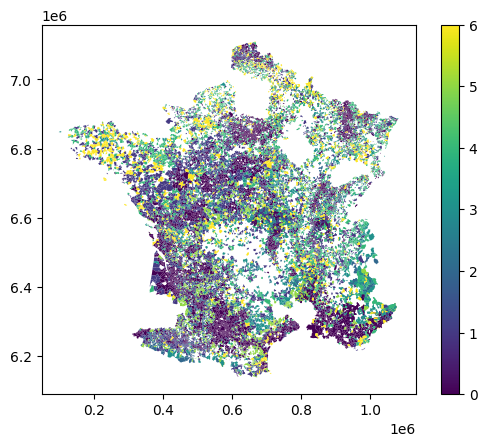

In [175]:
# Display Clustered communes on map
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:2153')
gdf.plot(column='cluster_hc', legend=True)